# RibbonDB-Flare-Analysis

In [54]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

In [ ]:
flare_csv = r"D:\Git_ALL_Projects\RibbonDB_v1.0\ribbondb_v1.0.csv"
flare_df = pd.read_csv(flare_csv)
flare_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3137 entries, 0 to 3136
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   INDEX            3137 non-null   int64  
 1    KEY             3137 non-null   str    
 2    TSTART [UT]     3137 non-null   str    
 3    TPEAK [UT]      3137 non-null   str    
 4    TFINAL [UT]     3137 non-null   str    
 5    IXPEAK [W/m^2]  3137 non-null   float64
 6    LAT [deg]       3137 non-null   int64  
 7    LON [deg]       3137 non-null   int64  
 8    ARNUM           3137 non-null   int64  
 9    PHI_AR [Mx]     3137 non-null   float64
 10   PHI_RBN [Mx]    3137 non-null   float64
 11   DPHI_RBN [Mx]   3137 non-null   float64
 12   S_AR [cm^2]     3137 non-null   float64
 13   S_RBN [cm^2]    3137 non-null   float64
 14   DS_RBN [cm^2]   3137 non-null   float64
 15   R_PHI [%]       3137 non-null   float64
 16   R_S[%]          3137 non-null   float64
dtypes: float64(9), int64(4), 

In [18]:
flare_df

,INDEX,KEY,TSTART [UT],TPEAK [UT],TFINAL [UT],IXPEAK [W/m^2],LAT [deg],LON [deg],ARNUM,PHI_AR [Mx],PHI_RBN [Mx],DPHI_RBN [Mx],S_AR [cm^2],S_RBN [cm^2],DS_RBN [cm^2],R_PHI [%],R_S[%]
0,0,20100612_0030_11081_M2.0,2010-06-12 00:30,2010-06-12 00:57,2010-06-12 01:02,0.000020,23,43,11081,1.839000e+22,3.209000e+21,7.712000e+20,9.199000e+19,4.441000e+18,1.158000e+18,17.5,4.8
1,1,20100713_1043_11087_C2.6,2010-07-13 10:43,2010-07-13 10:51,2010-07-13 10:55,0.000003,19,-26,11087,2.876000e+22,7.220000e+20,1.040000e+20,8.642000e+19,1.385000e+18,2.332000e+17,2.5,1.6
2,2,20100727_0412_11089_C2.2,2010-07-27 04:12,2010-07-27 04:24,2010-07-27 04:34,0.000002,-24,21,11089,3.280000e+22,1.617000e+21,4.311000e+20,1.043000e+20,3.394000e+18,9.310000e+17,4.9,3.3
3,3,20100801_0755_11092_C3.2,2010-08-01 07:55,2010-08-01 08:26,2010-08-01 09:35,0.000003,20,-36,11092,2.855000e+22,2.956000e+21,1.161000e+21,8.681000e+19,4.721000e+18,2.247000e+18,10.4,5.4
4,4,20100807_1755_11093_M1.0,2010-08-07 17:55,2010-08-07 18:24,2010-08-07 18:47,0.000010,11,-34,11093,3.031000e+22,4.754000e+21,5.771000e+20,8.570000e+19,9.502000e+18,1.229000e+18,15.7,11.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3132,3132,20160414_1321_12529_C1.8,2016-04-14 13:21,2016-04-14 13:32,2016-04-14 13:44,0.000002,11,14,12529,3.775000e+22,1.229000e+21,2.494000e+20,7.646000e+19,2.117000e+18,5.865000e+17,3.3,2.8
3133,3133,20160414_1759_12529_C1.3,2016-04-14 17:59,2016-04-14 18:07,2016-04-14 18:16,0.000001,12,7,12529,4.289000e+22,7.151000e+20,2.401000e+20,9.266000e+19,1.253000e+18,4.997000e+17,1.7,1.4
3134,3134,20160415_1404_12529_C4.1,2016-04-15 14:04,2016-04-15 14:30,2016-04-15 14:43,0.000004,11,20,12529,4.702000e+22,1.305000e+21,4.510000e+20,9.426000e+19,2.840000e+18,1.113000e+18,2.8,3.0
3135,3135,20160416_1942_12529_C5.8,2016-04-16 19:42,2016-04-16 19:58,2016-04-16 20:12,0.000006,13,43,12529,4.765000e+22,1.532000e+21,3.555000e+20,8.499000e+19,2.730000e+18,6.568000e+17,3.2,3.2


In [35]:
phi_rbn = flare_df[' PHI_RBN [Mx]']
ixpeak = flare_df[' IXPEAK [W/m^2]']
print(flare_df[[' PHI_RBN [Mx]', ' IXPEAK [W/m^2]']].head())


   PHI_RBN [Mx]  IXPEAK [W/m^2]
0  3.209000e+21        0.000020
1  7.220000e+20        0.000003
2  1.617000e+21        0.000002
3  2.956000e+21        0.000003
4  4.754000e+21        0.000010


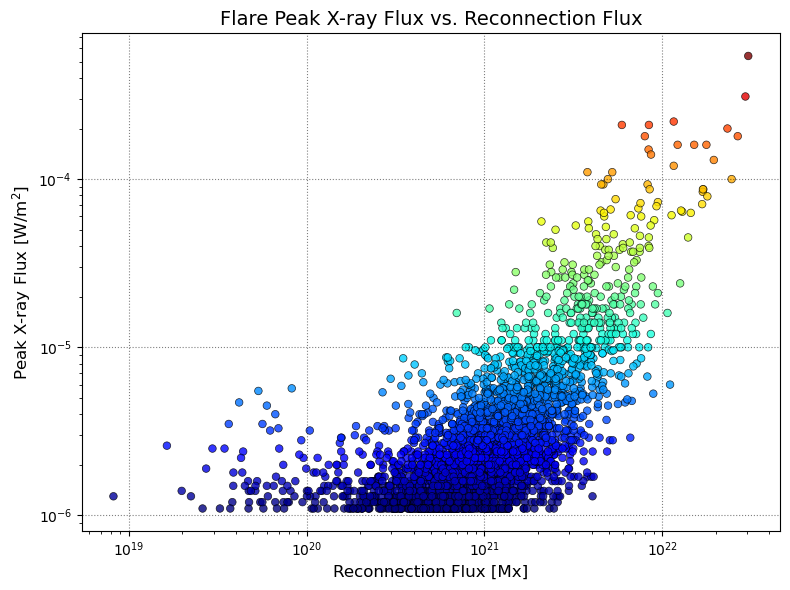

In [57]:
plt.figure(figsize=(8, 6))
plt.scatter(phi_rbn, ixpeak, c=ixpeak, cmap='jet', norm=LogNorm(), 
            s=30, edgecolors='k', linewidths=0.5, alpha=0.8)

# 5. Format axes to logarithmic scale
plt.xscale('log')
plt.yscale('log')

# 6. Apply grids and labels exactly as they appear in kazachenko.jpg
plt.grid(True, which="major", linestyle=':', color='black', alpha=0.5)
plt.xlabel(r'Reconnection Flux [Mx]', fontsize=12)
plt.ylabel(r'Peak X-ray Flux [W/m$^2$]', fontsize=12)
plt.title('Flare Peak X-ray Flux vs. Reconnection Flux', fontsize=14)

# 7. Save and display
plt.tight_layout()
plt.savefig('Bose_RibbonDB_Plot_Multicolor.png', dpi=300)
plt.show()